# Urban Mining Economics Analysis

## Research Question

How profitable is urban copper mining in Argentina?

## Objective

Estimate the economic value generated by urban recyclers through the recovery of copper-containing assets.

## Field Observation

The analysis is based on direct observation of urban recycling activities in Argentina, where collectors acquire household appliances and electric motors for material recovery.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(
    "../data/raw/urban_mining_field_data.csv"
)

df

,Activo,Cantidad_Semanal,Cobre_kg_por_unidad,Precio_Compra_ARS
0,Motor_secarropas,2,0.5,5000
1,Motor_lavarropas,2,0.6,5000
2,Transformador_microondas,3,0.7,5000
3,Aire_acondicionado,1,2.5,5000
4,Heladera,2,0.4,5000


In [3]:
df["Cobre_Semanal_kg"] = (
    df["Cantidad_Semanal"]
    * df["Cobre_kg_por_unidad"]
)

df

,Activo,Cantidad_Semanal,Cobre_kg_por_unidad,Precio_Compra_ARS,Cobre_Semanal_kg
0,Motor_secarropas,2,0.5,5000,1.0
1,Motor_lavarropas,2,0.6,5000,1.2
2,Transformador_microondas,3,0.7,5000,2.1
3,Aire_acondicionado,1,2.5,5000,2.5
4,Heladera,2,0.4,5000,0.8


In [4]:
df["Cobre_Mensual_kg"] = (
    df["Cobre_Semanal_kg"]
    * 4
)

df

,Activo,Cantidad_Semanal,Cobre_kg_por_unidad,Precio_Compra_ARS,Cobre_Semanal_kg,Cobre_Mensual_kg
0,Motor_secarropas,2,0.5,5000,1.0,4.0
1,Motor_lavarropas,2,0.6,5000,1.2,4.8
2,Transformador_microondas,3,0.7,5000,2.1,8.4
3,Aire_acondicionado,1,2.5,5000,2.5,10.0
4,Heladera,2,0.4,5000,0.8,3.2


In [5]:
precio_cobre = 15500

df["Ingreso_Mensual_ARS"] = (
    df["Cobre_Mensual_kg"]
    * precio_cobre
)

df

,Activo,Cantidad_Semanal,Cobre_kg_por_unidad,Precio_Compra_ARS,Cobre_Semanal_kg,Cobre_Mensual_kg,Ingreso_Mensual_ARS
0,Motor_secarropas,2,0.5,5000,1.0,4.0,62000.0
1,Motor_lavarropas,2,0.6,5000,1.2,4.8,74400.0
2,Transformador_microondas,3,0.7,5000,2.1,8.4,130200.0
3,Aire_acondicionado,1,2.5,5000,2.5,10.0,155000.0
4,Heladera,2,0.4,5000,0.8,3.2,49600.0


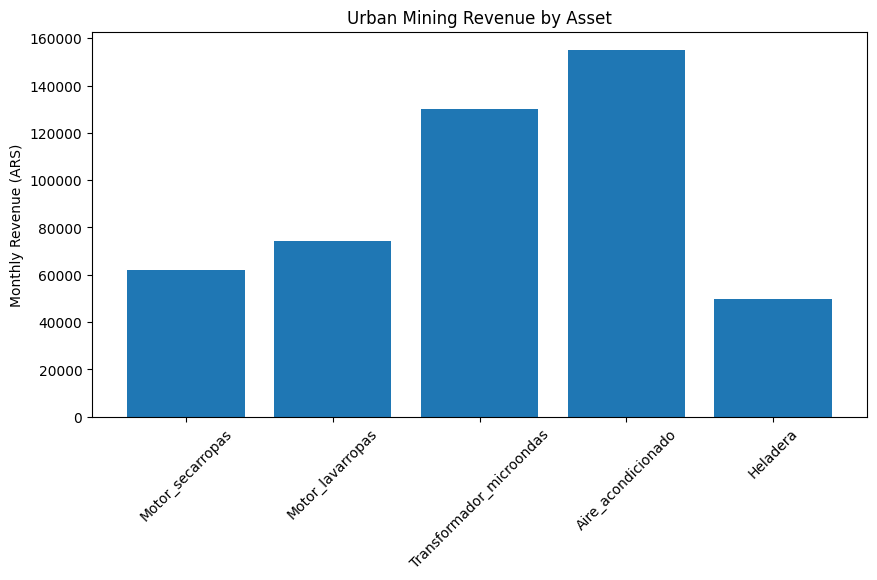

In [6]:
plt.figure(figsize=(10,5))

plt.bar(
    df["Activo"],
    df["Ingreso_Mensual_ARS"]
)

plt.xticks(rotation=45)

plt.title(
    "Urban Mining Revenue by Asset"
)

plt.ylabel(
    "Monthly Revenue (ARS)"
)

plt.show()

# Preliminary Findings

The analysis suggests that urban mining profitability varies significantly depending on the recovered asset.

Key findings:

* Air conditioning units appear to be the highest-value urban mining asset.
* Microwave transformers provide a high value-to-size ratio.
* Electric motors represent the core economic unit of urban copper recovery.
* Urban recyclers may improve profitability by prioritizing high-value assets.

These findings support the hypothesis that urban mining operates as a portfolio of recoverable assets rather than as a simple scrap collection activity.


In [7]:
# Resumen económico mensual

resumen = pd.DataFrame({
    "Cobre_total_mensual_kg": [df["Cobre_Mensual_kg"].sum()],
    "Ingreso_total_mensual_ARS": [df["Ingreso_Mensual_ARS"].sum()]
})

resumen

,Cobre_total_mensual_kg,Ingreso_total_mensual_ARS
0,30.4,471200.0


In [8]:
horas_mes = 40 * 4

ingreso_hora = (
    df["Ingreso_Mensual_ARS"].sum()
    / horas_mes
)

print(
    f"Ingreso por hora: ${ingreso_hora:,.0f} ARS"
)

Ingreso por hora: $2,945 ARS


In [9]:
ranking = df.sort_values(
    by="Ingreso_Mensual_ARS",
    ascending=False
)

ranking[
    [
        "Activo",
        "Cobre_Mensual_kg",
        "Ingreso_Mensual_ARS"
    ]
]

,Activo,Cobre_Mensual_kg,Ingreso_Mensual_ARS
3,Aire_acondicionado,10.0,155000.0
2,Transformador_microondas,8.4,130200.0
1,Motor_lavarropas,4.8,74400.0
0,Motor_secarropas,4.0,62000.0
4,Heladera,3.2,49600.0


In [10]:
# Factor de recuperación real

factor_recuperacion = 0.85

df["Cobre_Real_Mensual_kg"] = (
    df["Cobre_Mensual_kg"]
    * factor_recuperacion
)

df["Ingreso_Real_Mensual_ARS"] = (
    df["Cobre_Real_Mensual_kg"]
    * precio_cobre
)

df

,Activo,Cantidad_Semanal,Cobre_kg_por_unidad,Precio_Compra_ARS,Cobre_Semanal_kg,Cobre_Mensual_kg,Ingreso_Mensual_ARS,Cobre_Real_Mensual_kg,Ingreso_Real_Mensual_ARS
0,Motor_secarropas,2,0.5,5000,1.0,4.0,62000.0,3.40,52700.0
1,Motor_lavarropas,2,0.6,5000,1.2,4.8,74400.0,4.08,63240.0
2,Transformador_microondas,3,0.7,5000,2.1,8.4,130200.0,7.14,110670.0
3,Aire_acondicionado,1,2.5,5000,2.5,10.0,155000.0,8.50,131750.0
4,Heladera,2,0.4,5000,0.8,3.2,49600.0,2.72,42160.0


In [11]:
resumen_real = pd.DataFrame({
    "Cobre_Real_Total_kg": [
        df["Cobre_Real_Mensual_kg"].sum()
    ],
    "Ingreso_Real_Total_ARS": [
        df["Ingreso_Real_Mensual_ARS"].sum()
    ]
})

resumen_real

,Cobre_Real_Total_kg,Ingreso_Real_Total_ARS
0,25.84,400520.0


In [12]:
ingreso_hora_real = (
    df["Ingreso_Real_Mensual_ARS"].sum()
    / horas_mes
)

print(
    f"Ingreso real por hora: ${ingreso_hora_real:,.0f} ARS"
)

Ingreso real por hora: $2,503 ARS


In [13]:
ranking_real = df.sort_values(
    by="Ingreso_Real_Mensual_ARS",
    ascending=False
)

ranking_real[
    [
        "Activo",
        "Cobre_Real_Mensual_kg",
        "Ingreso_Real_Mensual_ARS"
    ]
]

,Activo,Cobre_Real_Mensual_kg,Ingreso_Real_Mensual_ARS
3,Aire_acondicionado,8.50,131750.0
2,Transformador_microondas,7.14,110670.0
1,Motor_lavarropas,4.08,63240.0
0,Motor_secarropas,3.40,52700.0
4,Heladera,2.72,42160.0


In [14]:
# Costo de adquisición

df["Costo_Mensual_ARS"] = (
    df["Cantidad_Semanal"]
    * 4
    * df["Precio_Compra_ARS"]
)

df["Ganancia_Bruta_ARS"] = (
    df["Ingreso_Real_Mensual_ARS"]
    - df["Costo_Mensual_ARS"]
)

df

,Activo,Cantidad_Semanal,Cobre_kg_por_unidad,Precio_Compra_ARS,Cobre_Semanal_kg,Cobre_Mensual_kg,Ingreso_Mensual_ARS,Cobre_Real_Mensual_kg,Ingreso_Real_Mensual_ARS,Costo_Mensual_ARS,Ganancia_Bruta_ARS
0,Motor_secarropas,2,0.5,5000,1.0,4.0,62000.0,3.40,52700.0,40000,12700.0
1,Motor_lavarropas,2,0.6,5000,1.2,4.8,74400.0,4.08,63240.0,40000,23240.0
2,Transformador_microondas,3,0.7,5000,2.1,8.4,130200.0,7.14,110670.0,60000,50670.0
3,Aire_acondicionado,1,2.5,5000,2.5,10.0,155000.0,8.50,131750.0,20000,111750.0
4,Heladera,2,0.4,5000,0.8,3.2,49600.0,2.72,42160.0,40000,2160.0


In [15]:
resumen_negocio = pd.DataFrame({
    "Ingresos": [
        df["Ingreso_Real_Mensual_ARS"].sum()
    ],
    "Costos": [
        df["Costo_Mensual_ARS"].sum()
    ],
    "Ganancia_Bruta": [
        df["Ganancia_Bruta_ARS"].sum()
    ]
})

resumen_negocio

,Ingresos,Costos,Ganancia_Bruta
0,400520.0,200000,200520.0


In [16]:
df["ROI_pct"] = (
    df["Ganancia_Bruta_ARS"]
    / df["Costo_Mensual_ARS"]
) * 100

df[
    [
        "Activo",
        "Costo_Mensual_ARS",
        "Ganancia_Bruta_ARS",
        "ROI_pct"
    ]
]

,Activo,Costo_Mensual_ARS,Ganancia_Bruta_ARS,ROI_pct
0,Motor_secarropas,40000,12700.0,31.75
1,Motor_lavarropas,40000,23240.0,58.10
2,Transformador_microondas,60000,50670.0,84.45
3,Aire_acondicionado,20000,111750.0,558.75
4,Heladera,40000,2160.0,5.40


In [17]:
df["Urban_Mining_Index"] = (
    df["Ganancia_Bruta_ARS"]
    / df["Ganancia_Bruta_ARS"].max()
) * 100

df[
    [
        "Activo",
        "Urban_Mining_Index"
    ]
].sort_values(
    "Urban_Mining_Index",
    ascending=False
)

,Activo,Urban_Mining_Index
3,Aire_acondicionado,100.000000
2,Transformador_microondas,45.342282
1,Motor_lavarropas,20.796421
0,Motor_secarropas,11.364653
4,Heladera,1.932886


In [ ]:
st.header("Gross Profit by Asset")

fig, ax = plt.subplots(figsize=(8,4))

ax.bar(
    ranking["Activo"],
    ranking["Ganancia_Bruta_ARS"]
)

ax.set_ylabel(
    "Gross Profit (ARS)"
)

plt.xticks(rotation=45)

st.pyplot(fig)